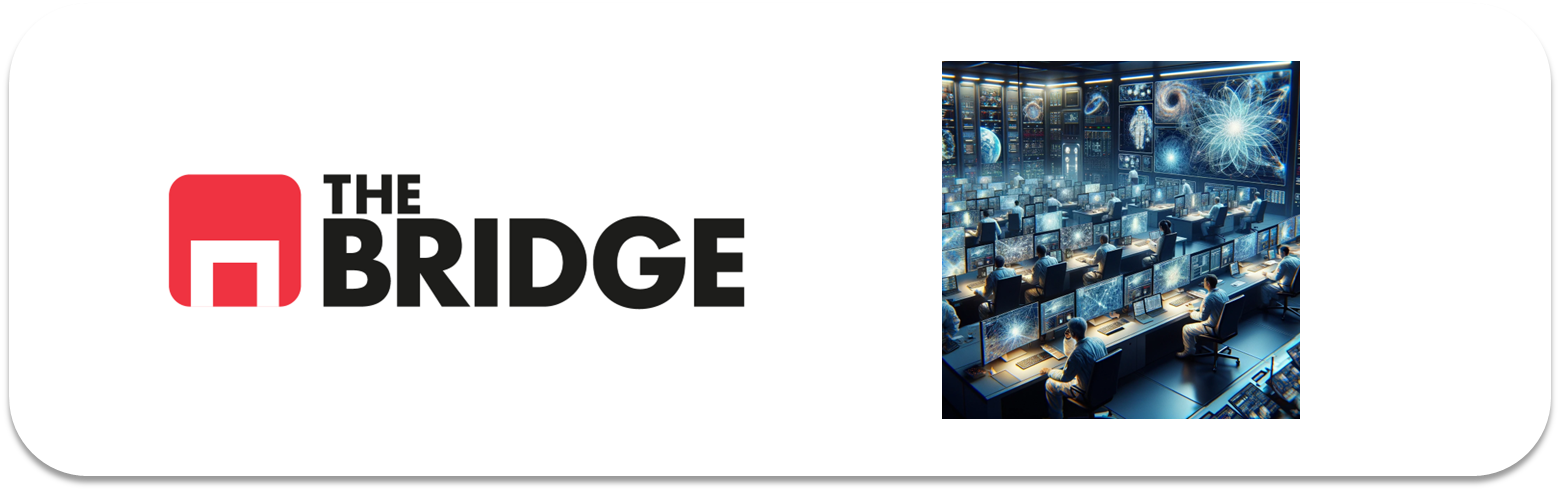

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import classification_report, ConfusionMatrixDisplay


### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



#### CONFIGURACIÓN Y CARGA DE LOS DATASET

In [2]:
IMG_SIZE = 160  # MobileNetV2 suele ir bien con 160 o 224
BATCH_SIZE = 32

TRAIN_DIR = "data/seg_train"
VAL_DIR   = "data/seg_train"   # si no tienes carpeta val
TEST_DIR  = "data/seg_test"



#### GENERADORES CON validation_split 

In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

classes = list(train_gen.class_indices.keys())
print("Clases:", classes)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Clases: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


#### TRANSFER LEARNING — MobileNetV2 BASE CONGELADA

In [4]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(classes), activation="softmax")(x)

model_tl = tf.keras.Model(inputs, outputs)

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### ENTRENAMIENTO — TRANSFER LEARNING

In [5]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_tl = model_tl.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 191s 530ms/step - accuracy: 0.3690 - loss: 1.4327 - val_accuracy: 0.4704 - val_loss: 1.2301
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 190s 540ms/step - accuracy: 0.4564 - loss: 1.2509 - val_accuracy: 0.5407 - val_loss: 1.1732
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 192s 547ms/step - accuracy: 0.4854 - loss: 1.1961 - val_accuracy: 0.5114 - val_loss: 1.1324
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 179s 510ms/step - accuracy: 0.5091 - loss: 1.1456 - val_accuracy: 0.5646 - val_loss: 1.0762
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 180s 512ms/step - accuracy: 0.5362 - loss: 1.1176 - val_accuracy: 0.6016 - val_loss: 1.0457
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 183s 521ms/step - accuracy: 0.5505 - loss: 1.0963 - val_accuracy: 0.5799 - val_loss: 1.0107
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 180s 512ms/step - accuracy: 0.5599 - loss: 1.0746 - val_accuracy: 0.5867 - val_loss: 1.0259
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 178s 508ms/step - accuracy: 0.5606 -

#### CURVAS DE ENTRENAMIENTO — TRANSFER LEARNING

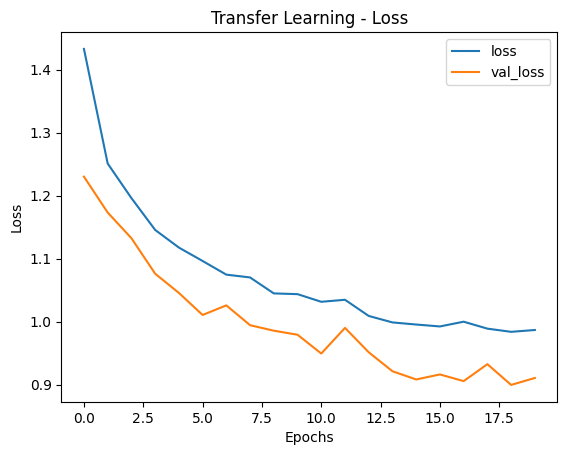

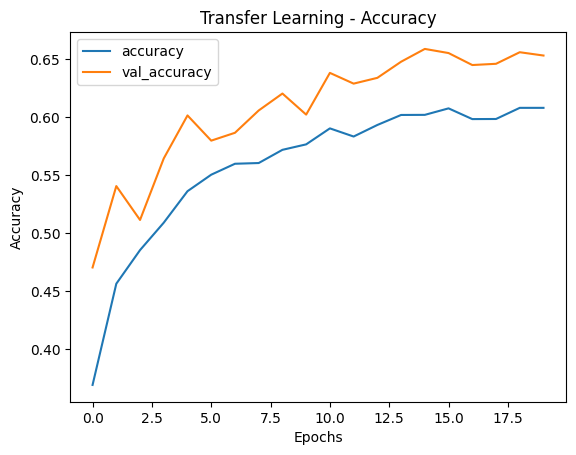

In [6]:
hist_tl_df = pd.DataFrame(history_tl.history)

hist_tl_df[["loss", "val_loss"]].plot()
plt.title("Transfer Learning - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

hist_tl_df[["accuracy", "val_accuracy"]].plot()
plt.title("Transfer Learning - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

La curva de loss (entrenamiento) y val_loss (validación) descienden de forma estable a lo largo de las épocas. Esto suele significar:

- El modelo está aprendiendo patrones reales, no ruido.
- No hay sobreajuste: la val_loss es incluso más baja que la loss, típico cuando:
- Usas transfer learning con pesos preentrenados.
- Congelas capas profundas que ya están muy bien ajustadas.
- El dataset de validación es más “fácil” o más limpio que el de entrenamiento.

Señales positivas:
- La caída es suave y sin oscilaciones bruscas.
- No hay divergencia entre loss y val_loss.
- No aparece el típico “val_loss sube mientras loss baja”, que indicaría sobreajuste.

La accuracy de entrenamiento sube de forma progresiva y se estabiliza alrededor de 0.60, mientras que la val_accuracy fluctúa pero llega a valores algo superiores (~0.65). Esto es típico en transfer learning cuando:

- El modelo ya tiene buenas representaciones iniciales.
- El dataset de validación es más fácil que el de entrenamiento.
- Hay data augmentation que hace el entrenamiento más difícil pero mejora la generalización.

Señales positivas:
- La tendencia general es ascendente.
- La validación supera al entrenamiento → buena generalización.
- No hay caída brusca de val_accuracy → no hay sobreajuste.

#### EVALUACIÓN — TRANSFER LEARNING

Transfer Learning - Test loss: 0.8742393255233765
Transfer Learning - Test accuracy: 0.6650000214576721
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 448ms/step
              precision    recall  f1-score   support

   buildings       0.65      0.69      0.67       437
      forest       0.83      0.89      0.86       474
     glacier       0.55      0.56      0.55       553
    mountain       0.59      0.68      0.63       525
         sea       0.63      0.53      0.58       510
      street       0.76      0.68      0.72       501

    accuracy                           0.67      3000
   macro avg       0.67      0.67      0.67      3000
weighted avg       0.67      0.67      0.66      3000



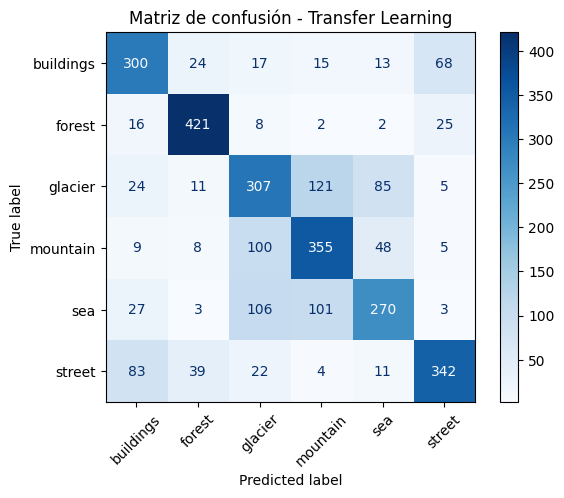

In [7]:
test_loss_tl, test_acc_tl = model_tl.evaluate(test_gen, verbose=0)
print("Transfer Learning - Test loss:", test_loss_tl)
print("Transfer Learning - Test accuracy:", test_acc_tl)

y_proba_tl = model_tl.predict(test_gen)
y_pred_tl = np.argmax(y_proba_tl, axis=1)
y_true = test_gen.classes

print(classification_report(y_true, y_pred_tl, target_names=classes))

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred_tl,
    display_labels=classes,
    cmap="Blues",
    xticks_rotation=45
)
plt.title("Matriz de confusión - Transfer Learning")
plt.show()

El modelo de transfer learning:

- Funciona bien para un primer entrenamiento.
- Generaliza correctamente (validación y test alineados).
- Diferencia muy bien clases con patrones visuales claros (forest, street).
- Tiene dificultades con clases visualmente similares (glacier, mountain, sea).
- No muestra sobreajuste, lo cual es una base sólida para seguir mejorando

#### FINE TUNING — DESCONGELAR ÚLTIMAS CAPAS

In [8]:
base_model.trainable = True
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model_ft = tf.keras.Model(model_tl.input, model_tl.output)

model_ft.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_ft.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 2,190,918 (8.36 MB)

 Non-trainable params: 396,544 (1.51 MB)

#### ENTRENAMIENTO — FINE TUNING

In [9]:

early_stop_ft = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_ft = model_ft.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=[early_stop_ft],
    verbose=1
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 291s 799ms/step - accuracy: 0.5040 - loss: 1.7281 - val_accuracy: 0.2293 - val_loss: 17.9677
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 284s 809ms/step - accuracy: 0.6544 - loss: 0.9168 - val_accuracy: 0.2653 - val_loss: 10.5898
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 283s 805ms/step - accuracy: 0.7081 - loss: 0.7773 - val_accuracy: 0.2193 - val_loss: 6.8173
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 282s 805ms/step - accuracy: 0.7494 - loss: 0.6673 - val_accuracy: 0.2279 - val_loss: 5.9388
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 285s 812ms/step - accuracy: 0.7770 - loss: 0.6117 - val_accuracy: 0.2878 - val_loss: 2.3566
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 286s 814ms/step - accuracy: 0.7943 - loss: 0.5574 - val_accuracy: 0.3606 - val_loss: 2.0425
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 285s 811ms/step - accuracy: 0.8127 - loss: 0.5055 - val_accuracy: 0.3242 - val_loss: 2.5319
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 284s 808ms/step - accuracy: 0.8335

# CURVAS — FINE TUNING

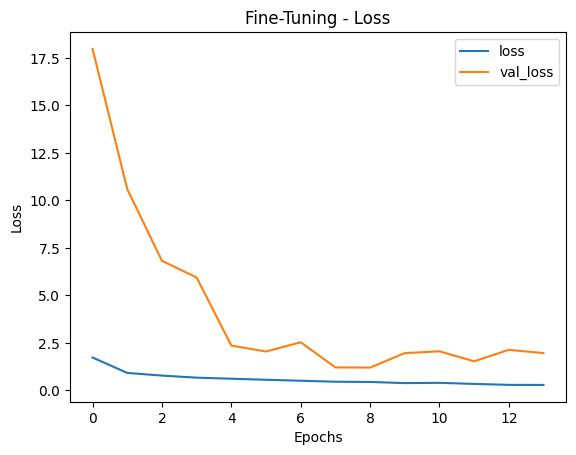

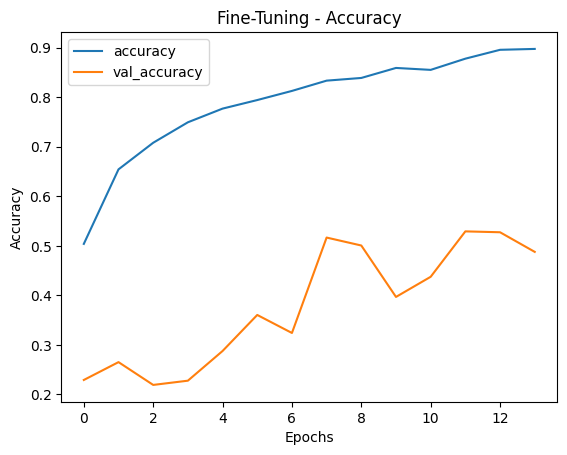

In [10]:
hist_ft_df = pd.DataFrame(history_ft.history)

hist_ft_df[["loss", "val_loss"]].plot()
plt.title("Fine-Tuning - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

hist_ft_df[["accuracy", "val_accuracy"]].plot()
plt.title("Fine-Tuning - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

Tu fine‑tuning no ha mejorado el modelo, sino que lo ha empeorado en validación.
El modelo:

- Memoriza el entrenamiento.
- Pierde capacidad de generalizar.
- Se vuelve inestable.
- No supera el rendimiento del transfer learning inicial.
- Esto es exactamente lo que se espera cuando el fine‑tuning no está bien regulado.

# EVALUACIÓN — FINE TUNING

Fine-Tuning - Test loss: 1.1907119750976562
Fine-Tuning - Test accuracy: 0.512666642665863
94/94 ━━━━━━━━━━━━━━━━━━━━ 43s 447ms/step
              precision    recall  f1-score   support

   buildings       0.77      0.41      0.54       437
      forest       0.95      0.45      0.61       474
     glacier       0.54      0.42      0.47       553
    mountain       0.58      0.10      0.17       525
         sea       0.42      0.80      0.55       510
      street       0.43      0.91      0.58       501

    accuracy                           0.51      3000
   macro avg       0.62      0.51      0.49      3000
weighted avg       0.61      0.51      0.48      3000



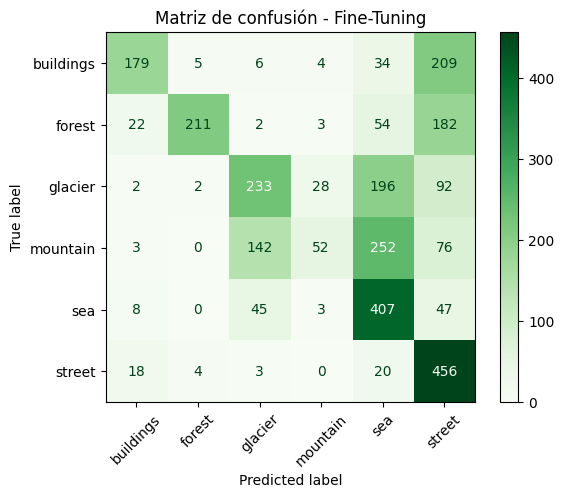

In [11]:
test_loss_ft, test_acc_ft = model_ft.evaluate(test_gen, verbose=0)
print("Fine-Tuning - Test loss:", test_loss_ft)
print("Fine-Tuning - Test accuracy:", test_acc_ft)

y_proba_ft = model_ft.predict(test_gen)
y_pred_ft = np.argmax(y_proba_ft, axis=1)

print(classification_report(y_true, y_pred_ft, target_names=classes))

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred_ft,
    display_labels=classes,
    cmap="Greens",
    xticks_rotation=45
)
plt.title("Matriz de confusión - Fine-Tuning")
plt.show()

El fine‑tuning ha empeorado el modelo. Los síntomas son los típicos de un ajuste demasiado agresivo:

- Sobreajuste severo.
- Pérdida de generalización.
- Colapso de clases hacia unas pocas categorías.
- Inestabilidad en validación y test.
- El modelo antes del fine‑tuning era claramente mejor.